# Earth tools and field development with NeqSim

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/earth_tools_and_field_development.ipynb)

This advanced, decision-oriented case links a transparent geospatial screening model to
NeqSim subsea-flow assurance. A synthetic discovery is routed to two synthetic host
facilities. Public-data interfaces are shown, but no real asset recommendation is made.

**Learning outcomes**

1. Select Python packages for vector, raster, network, and map work.
2. Keep geographic data in WGS84 for exchange and use a projected CRS for distance.
3. Build an auditable least-cost route from bathymetry, slope, and exclusion layers.
4. Pass route length, depth, and thermal assumptions into a NeqSim pipeline model.
5. Compare hosts with hydraulic, cost, uncertainty, and validation checks.

## Engineering question and boundaries

**Question:** Which host is the stronger screening candidate after spatial constraints and
NeqSim arrival conditions are considered together?

This is a concept-screening workflow, not detailed route engineering. The bathymetry,
discovery, hosts, exclusion area, tariffs, and costs are deliberately synthetic. Replace
them with governed project data before a decision. Coordinate operations use `always_xy`
and EPSG:32631 (UTM zone 31N); all distances below are planar metres in that CRS.

The route objective is

$$J=\sum_i \Delta s_i\left(1+w_s|\nabla z_i|+w_d d_i+w_e e_i\right)$$

where $z$ is water depth, $d$ is a normalized deep-water penalty, and $e$ is an
exclusion penalty. The weights are screening preferences, not physical laws.

## Package map

| Task | Packages demonstrated | Useful extensions |
|---|---|---|
| Vector geometry and CRS | `geopandas`, `shapely`, `pyproj` | `pyogrio`, PostGIS |
| Raster and labelled grids | `rasterio`, `rioxarray`, `xarray` | `odc-stac`, `stackstac` |
| Route and network analysis | `scikit-image`, `networkx` | `scipy`, `pyrosm` |
| Public data access | `requests` with SODIR REST/ArcGIS | `OWSLib`, `pystac-client` |
| Maps and 3-D review | `matplotlib`, `folium` | `contextily`, `PyVista` |
| Process and flow assurance | NeqSim Python bridge + current Java `master` | NeqSim process models |

SODIR publishes REST, WFS, WMS, ArcGIS, and downloadable datasets. A guarded refresh
example appears below; the executed case remains deterministic when a service is down.

In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys

PYTHON_NEQSIM_VERSION = "3.16.0"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")

try:
    installed_bridge_version = version("neqsim")
except PackageNotFoundError:
    installed_bridge_version = None
if installed_bridge_version != PYTHON_NEQSIM_VERSION:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            f"neqsim=={PYTHON_NEQSIM_VERSION}",
        ],
        check=True,
    )

using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ
if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype

if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )
jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm

init_jvm()
SOURCE_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded Java classes from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")

NeqSim Python bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 9e8d44a141bba600026d2229969b49af50f34237
NeqSim source JAR SHA-256: 4f65f4a3018c8d4f10b84c367c906de212c52b3dbd7b133f0887550df5d9552e
Loaded Java classes from: file:/workspace/scratch/6302cef4de4f/neqsim-java-master/target/neqsim-3.16.0.jar
Python runtime: 3.12.13


In [2]:
from importlib.metadata import version
import math
import warnings

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import rasterio
import requests
import rioxarray
import xarray as xr
from IPython.display import display
from pyproj import Transformer
from rasterio.features import rasterize
from rasterio.transform import from_origin
from shapely.geometry import LineString, Point, Polygon, mapping
from skimage.graph import route_through_array

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")

used_packages = [
    "geopandas",
    "shapely",
    "pyproj",
    "rasterio",
    "rioxarray",
    "xarray",
    "scikit-image",
    "networkx",
    "folium",
]
display(pd.DataFrame(
    {"package": used_packages, "version": [version(name) for name in used_packages]}
))

,package,version
0,geopandas,1.1.4
1,shapely,2.1.2
2,pyproj,3.7.2
3,rasterio,1.5.0
4,rioxarray,0.23.0
5,xarray,2026.7.0
6,scikit-image,0.26.0
7,networkx,3.6.1
8,folium,0.20.0


## Optional public-data refresh

The official SODIR FactMaps REST base is `https://factmaps.sodir.no/api/rest`.
Layer 311 contains pipelines, layer 504 discoveries by main hydrocarbon type, and layer
616 current production licences with geometry. The small request below is opt-in to keep
the teaching result reproducible and kind to public services. Inspect service metadata
and licensing before operational use.

In [3]:
ENABLE_LIVE_SODIR = False
SODIR_REST_BASE = "https://factmaps.sodir.no/api/rest"
SODIR_LAYER_IDS = {
    "pipelines": 311,
    "discoveries": 504,
    "current_licences": 616,
}

if ENABLE_LIVE_SODIR:
    response = requests.get(SODIR_REST_BASE, timeout=30)
    response.raise_for_status()
    print("SODIR REST endpoint is reachable:", response.url)
else:
    print("Live SODIR refresh disabled; using the documented synthetic case.")

Live SODIR refresh disabled; using the documented synthetic case.


## 1. Create governed vector layers

Exchange data remain in EPSG:4326. We reproject once to EPSG:32631 before measuring,
buffering, rasterizing, or routing. The exclusion polygon represents a generic protected
or restricted area and receives a very large—not infinite—cost so its effect is visible.

In [4]:
crs_geo = "EPSG:4326"
crs_projected = "EPSG:32631"

assets_geo = gpd.GeoDataFrame(
    {
        "name": ["Discovery", "Host West", "Host East"],
        "kind": ["discovery", "host", "host"],
    },
    geometry=[Point(2.55, 60.55), Point(2.08, 60.78), Point(3.03, 60.30)],
    crs=crs_geo,
)
exclusion_geo = gpd.GeoDataFrame(
    {"name": ["Screening exclusion"]},
    geometry=[
        Polygon([
            (2.27, 60.57),
            (2.42, 60.59),
            (2.45, 60.73),
            (2.28, 60.75),
        ])
    ],
    crs=crs_geo,
)
assets = assets_geo.to_crs(crs_projected)
exclusion = exclusion_geo.to_crs(crs_projected)
display(assets.assign(easting=assets.geometry.x, northing=assets.geometry.y))

assert assets.crs.to_epsg() == 32631
assert exclusion.geometry.is_valid.all()
assert assets.geometry.is_unique

,name,kind,geometry,easting,northing
0,Discovery,discovery,POINT (475317.962 6712750.4),475317.962159,6.712750e+06
1,Host West,host,POINT (449898.393 6738634.223),449898.392905,6.738634e+06
2,Host East,host,POINT (501658.157 6684822.647),501658.157329,6.684823e+06


## 2. Build an `xarray`/`rioxarray` bathymetry surface

The raster is synthetic but structured: regional depth trend, banks/troughs, and a smooth
undulation. `rasterio` supplies the affine transform used to rasterize the vector
constraint. In a project, this array could be replaced by EMODnet, GEBCO, or a surveyed
GeoTIFF after resolution, datum, coverage, and licence checks.

In [5]:
margin_m = 15_000.0
x_min, y_min, x_max, y_max = assets.total_bounds
x = np.linspace(x_min - margin_m, x_max + margin_m, 180)
y = np.linspace(y_max + margin_m, y_min - margin_m, 150)
xx, yy = np.meshgrid(x, y)

xn = (xx - xx.mean()) / 1_000.0
yn = (yy - yy.mean()) / 1_000.0
water_depth_m = (
    250.0
    + 0.55 * xn
    - 0.22 * yn
    + 42.0 * np.sin(xn / 12.0) * np.cos(yn / 15.0)
)
water_depth_m += 90.0 * np.exp(-((xn - 8.0) ** 2 + (yn + 4.0) ** 2) / 250.0)
water_depth_m = np.clip(water_depth_m, 90.0, 620.0)

bathymetry = xr.DataArray(
    water_depth_m,
    coords={"y": y, "x": x},
    dims=("y", "x"),
    name="water_depth_m",
).rio.write_crs(crs_projected)

dx = float(abs(x[1] - x[0]))
dy = float(abs(y[1] - y[0]))
transform = from_origin(x.min() - dx / 2, y.max() + dy / 2, dx, dy)
exclusion_mask = rasterize(
    [(mapping(exclusion.geometry.iloc[0]), 1)],
    out_shape=water_depth_m.shape,
    transform=transform,
    fill=0,
    dtype="uint8",
)
assert bathymetry.rio.crs.to_epsg() == 32631
assert exclusion_mask.max() == 1
print(bathymetry)

<xarray.DataArray 'water_depth_m' (y: 150, x: 180)> Size: 216kB
array([[207.95307113, 209.66183774, 211.38347721, ..., 270.17830793,
        271.89991047, 273.60864384],
       [208.22471418, 209.91264088, 211.61325638, ..., 270.19610165,
        271.89667181, 273.58455768],
       [208.51069318, 210.17575989, 211.85331352, ..., 270.20363337,
        271.88113147, 273.54614817],
       ...,
       [226.45427163, 228.11934346, 229.79690315, ..., 288.15343487,
        289.83023937, 291.49463122],
       [226.41578592, 228.10371697, 229.80433761, ..., 288.39245528,
        290.09243675, 291.77979227],
       [226.39163671, 228.100407  , 229.82205082, ..., 288.62134478,
        290.34244897, 292.05073339]], shape=(150, 180))
Coordinates:
  * y            (y) float64 1kB 6.754e+06 6.753e+06 ... 6.67e+06 6.67e+06
  * x            (x) float64 1kB 4.349e+05 4.354e+05 ... 5.162e+05 5.167e+05
    spatial_ref  int64 8B 0


## 3. Form the least-cost surface and route candidates

Cell traversal cost combines seabed slope, normalized water depth, and the rasterized
exclusion. `route_through_array` permits diagonal movement and returns the minimum-cost
grid path. `networkx` then represents the candidate tie-backs as an auditable host graph.

In [6]:
dz_dy, dz_dx = np.gradient(water_depth_m, dy, dx)
slope = np.hypot(dz_dx, dz_dy)
depth_penalty = (water_depth_m - water_depth_m.min()) / np.ptp(water_depth_m)
cost_surface = 1.0 + 16.0 * slope + 1.4 * depth_penalty
cost_surface += exclusion_mask * 250.0


def nearest_cell(point):
    col = int(np.argmin(np.abs(x - point.x)))
    row = int(np.argmin(np.abs(y - point.y)))
    return row, col


def route_to_host(host_name):
    discovery_point = assets.loc[assets["kind"] == "discovery", "geometry"].iloc[0]
    host_point = assets.loc[assets["name"] == host_name, "geometry"].iloc[0]
    start = nearest_cell(discovery_point)
    finish = nearest_cell(host_point)
    cells, accumulated_cost = route_through_array(
        cost_surface,
        start,
        finish,
        fully_connected=True,
        geometric=True,
    )
    coords = [(x[col], y[row]) for row, col in cells]
    line = LineString(coords)
    sampled_depth = np.array([water_depth_m[row, col] for row, col in cells])
    sampled_exclusion = np.array([exclusion_mask[row, col] for row, col in cells])
    segment_lengths = np.hypot(np.diff(line.xy[0]), np.diff(line.xy[1]))
    cumulative = np.r_[0.0, np.cumsum(segment_lengths)]
    return {
        "host": host_name,
        "geometry": line,
        "route_km": line.length / 1_000.0,
        "straight_km": discovery_point.distance(host_point) / 1_000.0,
        "mean_depth_m": sampled_depth.mean(),
        "max_depth_m": sampled_depth.max(),
        "exclusion_cells": int(sampled_exclusion.sum()),
        "accumulated_cost": float(accumulated_cost),
        "distance_km": cumulative / 1_000.0,
        "depth_profile_m": sampled_depth,
    }


routes = [route_to_host("Host West"), route_to_host("Host East")]
route_table = pd.DataFrame(
    [{key: value for key, value in item.items() if not isinstance(value, (LineString, np.ndarray))}
     for item in routes]
)
display(route_table.round(2))

graph = nx.Graph()
graph.add_node("Discovery", kind="source")
for item in routes:
    graph.add_edge(
        "Discovery",
        item["host"],
        distance_km=item["route_km"],
        route_cost=item["accumulated_cost"],
    )
assert nx.is_connected(graph)
assert (route_table["route_km"] >= route_table["straight_km"]).all()
assert (route_table["exclusion_cells"] == 0).all()

,host,route_km,straight_km,mean_depth_m,max_depth_m,exclusion_cells,accumulated_cost
0,Host West,43.34,36.28,231.89,307.64,0,110.58
1,Host East,39.62,38.39,313.17,357.64,0,157.60


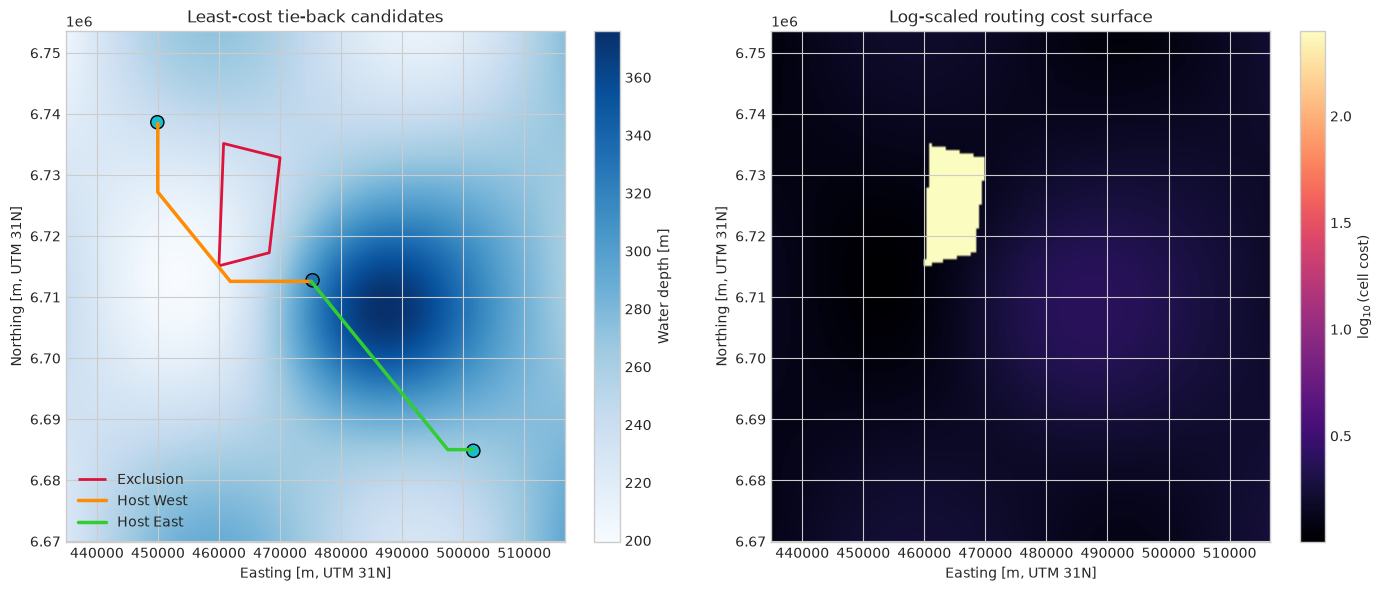

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)

depth_image = axes[0].imshow(
    water_depth_m,
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="Blues",
    origin="upper",
)
exclusion.boundary.plot(ax=axes[0], color="crimson", linewidth=2, label="Exclusion")
for item, color in zip(routes, ["darkorange", "limegreen"]):
    xs, ys = item["geometry"].xy
    axes[0].plot(xs, ys, color=color, linewidth=2.5, label=item["host"])
assets.plot(
    ax=axes[0],
    column="kind",
    categorical=True,
    markersize=90,
    edgecolor="black",
    legend=True,
)
axes[0].set_title("Least-cost tie-back candidates")
axes[0].set_xlabel("Easting [m, UTM 31N]")
axes[0].set_ylabel("Northing [m, UTM 31N]")
axes[0].legend(loc="lower left")
fig.colorbar(depth_image, ax=axes[0], label="Water depth [m]")

cost_image = axes[1].imshow(
    np.log10(cost_surface),
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="magma",
    origin="upper",
)
axes[1].set_title("Log-scaled routing cost surface")
axes[1].set_xlabel("Easting [m, UTM 31N]")
axes[1].set_ylabel("Northing [m, UTM 31N]")
fig.colorbar(cost_image, ax=axes[1], label=r"$\log_{10}$(cell cost)")
plt.show()

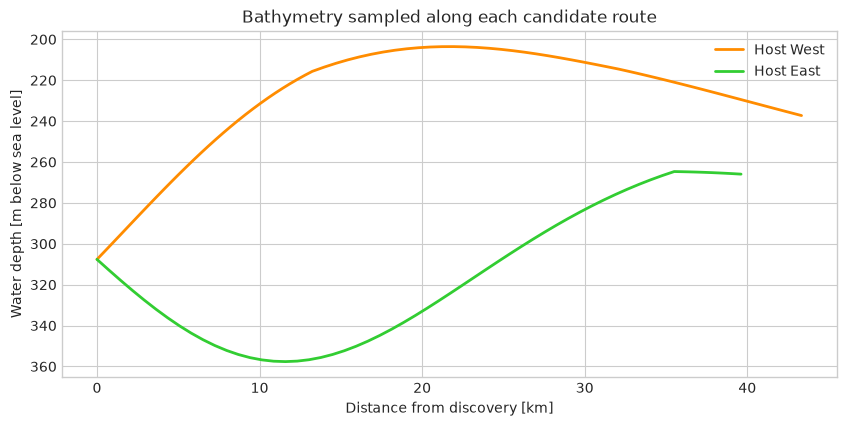

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for item, color in zip(routes, ["darkorange", "limegreen"]):
    ax.plot(
        item["distance_km"],
        item["depth_profile_m"],
        color=color,
        linewidth=2,
        label=item["host"],
    )
ax.invert_yaxis()
ax.set_xlabel("Distance from discovery [km]")
ax.set_ylabel("Water depth [m below sea level]")
ax.set_title("Bathymetry sampled along each candidate route")
ax.legend()
plt.show()

## 4. Couple route geometry to NeqSim

Each route becomes a steady-state `PipeBeggsAndBrills` case. Route length comes directly
from the spatial model; outlet elevation is the negative host water depth relative to the
discovery. A constant seabed temperature and overall heat-transfer coefficient provide a
screening thermal boundary. A later design phase should segment the detailed profile and
calibrate roughness, insulation, heat transfer, and multiphase behaviour.

In [9]:
J = jpype.JClass
SystemSrkEos = J("neqsim.thermo.system.SystemSrkEos")
Stream = J("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = J("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")


def make_wellstream():
    fluid = SystemSrkEos(273.15 + 64.0, 175.0)
    for component, fraction in {
        "nitrogen": 0.012,
        "CO2": 0.018,
        "methane": 0.832,
        "ethane": 0.075,
        "propane": 0.038,
        "n-butane": 0.012,
        "n-pentane": 0.006,
        "n-hexane": 0.003,
        "water": 0.004,
    }.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


def run_route_pipeline(route):
    inlet = Stream(f"{route['host']} inlet", make_wellstream())
    inlet.setFlowRate(1.35, "MSm3/day")
    inlet.setTemperature(64.0, "C")
    inlet.setPressure(175.0, "bara")
    inlet.run()

    pipe = PipeBeggsAndBrills(f"{route['host']} tie-back", inlet)
    pipe.setLength(route["route_km"] * 1_000.0)
    pipe.setDiameter(0.3556)
    pipe.setPipeWallRoughness(4.5e-5)
    pipe.setElevation(route["depth_profile_m"][0] - route["depth_profile_m"][-1])
    pipe.setNumberOfIncrements(max(30, int(route["route_km"])))
    pipe.setConstantSurfaceTemperature(5.0, "C")
    pipe.setHeatTransferCoefficient(2.2)
    pipe.run()

    outlet = pipe.getOutletStream()
    return {
        "host": route["host"],
        "route_km": route["route_km"],
        "arrival_pressure_bara": outlet.getPressure("bara"),
        "arrival_temperature_C": outlet.getTemperature("C"),
        "inlet_flow_MSm3_d": inlet.getFlowRate("MSm3/day"),
        "outlet_flow_MSm3_d": outlet.getFlowRate("MSm3/day"),
    }


hydraulics = pd.DataFrame([run_route_pipeline(route) for route in routes])
display(hydraulics.round(3))

,host,route_km,arrival_pressure_bara,arrival_temperature_C,inlet_flow_MSm3_d,outlet_flow_MSm3_d
0,Host West,43.335,172.553,10.998,1.35,1.35
1,Host East,39.616,173.229,12.293,1.35,1.35


For a screening check, mass flow should be conserved and all reported pressures must be
finite and positive. A longer route is expected to have no smaller pressure drop when the
other inputs are equal; bathymetric elevation can modify that simple trend.

Maximum relative stream-flow imbalance: 0.00e+00


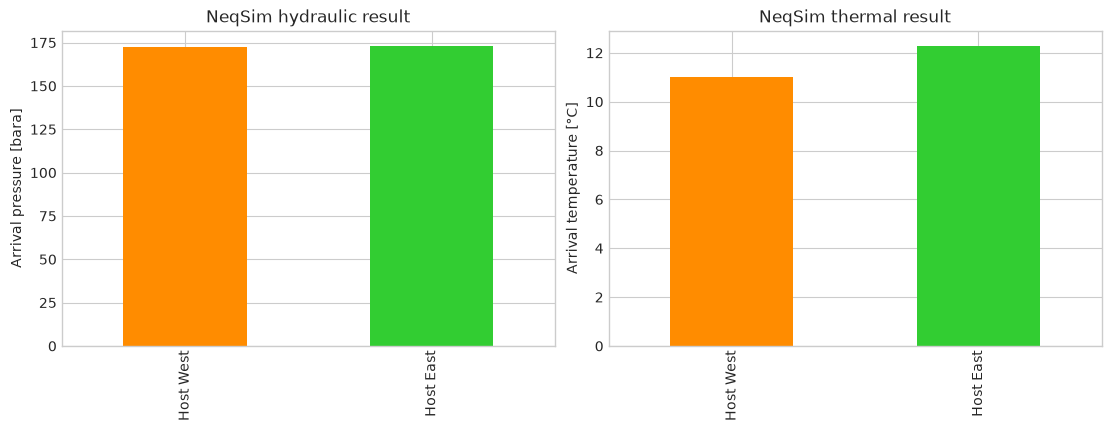

In [10]:
hydraulics["pressure_drop_bar"] = 175.0 - hydraulics["arrival_pressure_bara"]
relative_balance_error = (
    (hydraulics["outlet_flow_MSm3_d"] - hydraulics["inlet_flow_MSm3_d"]).abs()
    / hydraulics["inlet_flow_MSm3_d"]
)

assert np.isfinite(hydraulics["arrival_pressure_bara"]).all()
assert (hydraulics["arrival_pressure_bara"] > 1.0).all()
assert (relative_balance_error < 1e-7).all()
assert (hydraulics["arrival_temperature_C"] < 64.0).all()
print("Maximum relative stream-flow imbalance:", f"{relative_balance_error.max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
hydraulics.plot.bar(
    x="host",
    y="arrival_pressure_bara",
    ax=axes[0],
    color=["darkorange", "limegreen"],
    legend=False,
)
axes[0].set_ylabel("Arrival pressure [bara]")
axes[0].set_xlabel("")
axes[0].set_title("NeqSim hydraulic result")
hydraulics.plot.bar(
    x="host",
    y="arrival_temperature_C",
    ax=axes[1],
    color=["darkorange", "limegreen"],
    legend=False,
)
axes[1].set_ylabel("Arrival temperature [°C]")
axes[1].set_xlabel("")
axes[1].set_title("NeqSim thermal result")
plt.show()

## 5. Translate technical results into a host screen

The economic layer is intentionally simple and exposed. Subsea CAPEX scales with routed
length and a depth factor; tariff and brownfield modification are host-specific. The
discounted project value is

$$NPV=-C_0+\sum_{t=1}^{n}\frac{R_t-O_t}{(1+r)^t}$$

No uncertainty distribution, tax model, production decline, uptime model, or abandonment
cost is implied. Those are natural extensions after the spatial/process coupling works.

In [11]:
screen = route_table.merge(hydraulics, on=["host", "route_km"])
screen["capex_MUSD"] = (
    115.0
    + 2.15 * screen["route_km"]
    + 0.075 * screen["max_depth_m"]
)
screen["host_modification_MUSD"] = screen["host"].map(
    {"Host West": 78.0, "Host East": 48.0}
)
screen["annual_tariff_MUSD"] = screen["host"].map(
    {"Host West": 24.0, "Host East": 31.0}
)
screen["total_capex_MUSD"] = screen["capex_MUSD"] + screen["host_modification_MUSD"]

annual_revenue_MUSD = 122.0
annual_opex_MUSD = 14.0
discount_rate = 0.08
years = np.arange(1, 11)
annuity_factor = np.sum(1.0 / (1.0 + discount_rate) ** years)
screen["screening_NPV_MUSD"] = (
    -screen["total_capex_MUSD"]
    + (
        annual_revenue_MUSD
        - annual_opex_MUSD
        - screen["annual_tariff_MUSD"]
    ) * annuity_factor
)
screen["pressure_margin_bar"] = screen["arrival_pressure_bara"] - 70.0
screen["rank"] = screen["screening_NPV_MUSD"].rank(ascending=False).astype(int)

display(screen[[
    "host",
    "route_km",
    "max_depth_m",
    "arrival_pressure_bara",
    "pressure_margin_bar",
    "total_capex_MUSD",
    "screening_NPV_MUSD",
    "rank",
]].round(2).sort_values("rank"))

assert (screen["pressure_margin_bar"] > 0.0).all()
assert np.isfinite(screen["screening_NPV_MUSD"]).all()

,host,route_km,max_depth_m,arrival_pressure_bara,pressure_margin_bar,total_capex_MUSD,screening_NPV_MUSD,rank
0,Host West,43.34,307.64,172.55,102.55,309.24,254.40,1
1,Host East,39.62,357.64,173.23,103.23,275.00,241.68,2


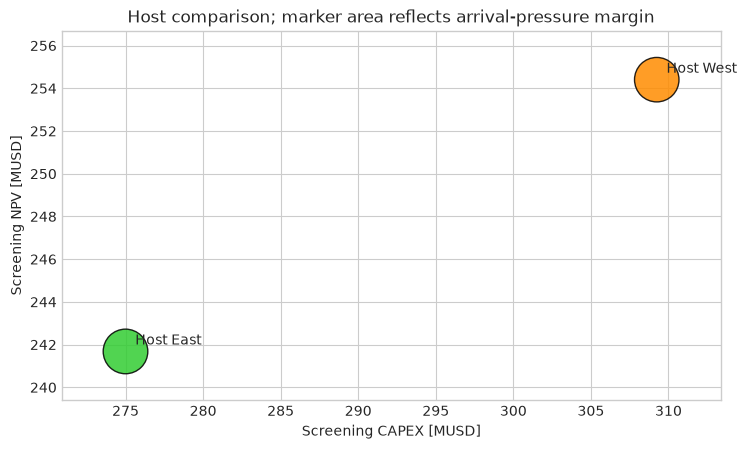

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = ["darkorange" if host == "Host West" else "limegreen" for host in screen["host"]]
scatter = ax.scatter(
    screen["total_capex_MUSD"],
    screen["screening_NPV_MUSD"],
    s=10.0 * screen["pressure_margin_bar"],
    c=colors,
    edgecolor="black",
    alpha=0.85,
)
for _, row in screen.iterrows():
    ax.annotate(row["host"], (row["total_capex_MUSD"], row["screening_NPV_MUSD"]),
                xytext=(7, 5), textcoords="offset points")
ax.set_xlabel("Screening CAPEX [MUSD]")
ax.set_ylabel("Screening NPV [MUSD]")
ax.set_title("Host comparison; marker area reflects arrival-pressure margin")
ax.margins(x=0.12, y=0.18)
plt.show()

## Interactive map (with a static result above)

`folium` is convenient for stakeholder review in Colab. It is not a substitute for a
project GIS: the geometry is converted back to WGS84, styling is simplified, and layer
metadata are not preserved.

In [13]:
transformer = Transformer.from_crs(crs_projected, crs_geo, always_xy=True)
map_view = folium.Map(location=[60.55, 2.55], zoom_start=8, tiles="CartoDB positron")
for _, row in assets_geo.iterrows():
    folium.Marker(
        [row.geometry.y, row.geometry.x],
        tooltip=f"{row['kind']}: {row['name']}",
    ).add_to(map_view)
for item, color in zip(routes, ["orange", "green"]):
    lon_lat = [transformer.transform(xv, yv) for xv, yv in item["geometry"].coords]
    folium.PolyLine(
        [(lat, lon) for lon, lat in lon_lat],
        color=color,
        weight=4,
        tooltip=f"{item['host']}: {item['route_km']:.1f} km",
    ).add_to(map_view)
folium.GeoJson(
    exclusion_geo.__geo_interface__,
    name="Screening exclusion",
    style_function=lambda _: {"color": "crimson", "fillOpacity": 0.15},
).add_to(map_view)
map_view

## Decision, limitations, and next work

The executed ranking identifies the preferred **screening** host under the stated weights
and commercial assumptions. The important result is the traceable chain: CRS-controlled
geometry → rasterized constraints → route attributes → NeqSim arrival conditions → a
visible decision table.

Before a project decision, replace the synthetic layers; verify vertical and horizontal
datums; include geohazards, soil, crossings, free spans, installation method, and survey
resolution; segment the actual elevation profile in NeqSim; calibrate the fluid and heat
transfer; and run probabilistic cost/schedule cases. Useful package extensions are
`pystac-client`/`stackstac` for catalogs, `PyVista` for 3-D review, and PostGIS for governed
multi-user data.

**Exercises**

1. Sweep slope and exclusion weights and plot how often each host wins.
2. Replace the synthetic raster with a licensed public GeoTIFF and record its checksum.
3. Segment each route into NeqSim pipes and compare against the one-segment approximation.
4. Add a third host and use `networkx` to test a shared-hub network.